
# Prediction with a pre-trained model 

In [1]:
from unet3 import unet
import numpy as np
from tensorflow.keras.optimizers import Adam

# Build the exact architecture used in train.py
loaded_model = unet(input_size=(None, None, None, 1))
loaded_model.compile(optimizer=Adam(learning_rate=1e-4),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

# load weights into model
loaded_model.load_weights("check1/fseg.hdf5")
print("Loaded model and weights from disk")

# training image dimensions
n1, n2, n3 = 96, 96, 96

2026-05-08 00:27:10.221305: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, None, None,  0                                            
__________________________________________________________________________________________________
conv3d (Conv3D)                 (None, None, None, N 448         input_1[0][0]                    
__________________________________________________________________________________________________
conv3d_1 (Conv3D)               (None, None, None, N 6928        conv3d[0][0]                     
__________________________________________________________________________________________________
max_pooling3d (MaxPooling3D)    (None, None, None, N 0           conv3d_1[0][0]                   
______________________________________________________________________________________________

2026-05-08 00:27:10.223867: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-08 00:27:10.232129: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-08 00:27:10.234379: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-08 00:27:10.236639: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-08 00:27:10.238869: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

In [2]:
# set gaussian weights in overlap boundaries for current patch size
def getMask(os, n1, n2, n3):
    sc = np.zeros((n1, n2, n3), dtype=np.single)
    sc = sc + 1
    sp = np.zeros((os), dtype=np.single)
    sig = os / 4
    sig = 0.5 / (sig * sig)
    for ks in range(os):
        ds = ks - os + 1
        sp[ks] = np.exp(-ds * ds * sig)
    for k1 in range(os):
        for k2 in range(n2):
            for k3 in range(n3):
                sc[k1][k2][k3] = sp[k1]
                sc[n1 - k1 - 1][k2][k3] = sp[k1]
    for k1 in range(n1):
        for k2 in range(os):
            for k3 in range(n3):
                sc[k1][k2][k3] = sp[k2]
                sc[k1][n2 - k2 - 1][k3] = sp[k2]
    for k1 in range(n1):
        for k2 in range(n2):
            for k3 in range(os):
                sc[k1][k2][k3] = sp[k3]
                sc[k1][k2][n3 - k3 - 1] = sp[k3]
    return sc

## ======================================================================


## prediction test on a training image 

2026-05-08 00:27:15.044740: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2026-05-08 00:27:15.868185: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8100


1/1 [==============================] - 2s 2s/step


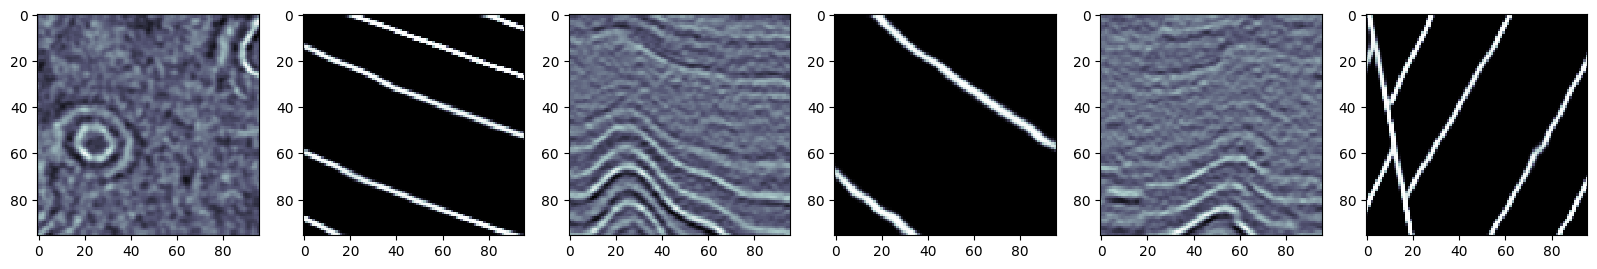

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

graw = np.fromfile("data/train/seis/8.dat", dtype=np.single)
raw_n = int(round(graw.size ** (1 / 3)))
graw = np.reshape(graw, (raw_n, raw_n, raw_n))

# Center-crop raw cube to model input size (n1, n2, n3).
s1 = (raw_n - n1) // 2
s2 = (raw_n - n2) // 2
s3 = (raw_n - n3) // 2
gx = graw[s1:s1+n1, s2:s2+n2, s3:s3+n3]

# Match training preprocessing in DataGenerator: z-score + transpose.
gx = gx - np.mean(gx)
gx = gx / (np.std(gx) + 1e-8)
gx = np.transpose(gx)
x = np.reshape(gx, (1, n1, n2, n3, 1))
Y = loaded_model.predict(x, verbose=1)
fig = plt.figure(figsize=(20,20))

# Slice indices valid for current input size
k1 = n1 // 2
k2 = n2 // 2
k3 = n3 // 2

# inline slice
plt.subplot(1, 6, 1)
imgplot1 = plt.imshow(np.transpose(x[0, k1, :, :, 0]).T, cmap=plt.cm.bone, interpolation='nearest', aspect=1)
plt.subplot(1, 6, 2)
imgplot2 = plt.imshow(np.transpose(Y[0, k1, :, :, 0]).T, cmap=plt.cm.bone, interpolation='nearest', aspect=1)

# xline slice
plt.subplot(1, 6, 3)
imgplot1 = plt.imshow(np.transpose(x[0, :, k2, :, 0]).T, cmap=plt.cm.bone, interpolation='nearest', aspect=1)
plt.subplot(1, 6, 4)
imgplot2 = plt.imshow(np.transpose(Y[0, :, k2, :, 0]).T, cmap=plt.cm.bone, interpolation='nearest', aspect=1)

# time slice
plt.subplot(1, 6, 5)
imgplot1 = plt.imshow(np.transpose(x[0, :, :, k3, 0]).T, cmap=plt.cm.bone, interpolation='nearest', aspect=1)
plt.subplot(1, 6, 6)
imgplot2 = plt.imshow(np.transpose(Y[0, :, :, k3, 0]).T, cmap=plt.cm.bone, interpolation='nearest', aspect=1)

1/1 [==============================] - 0s 24ms/step


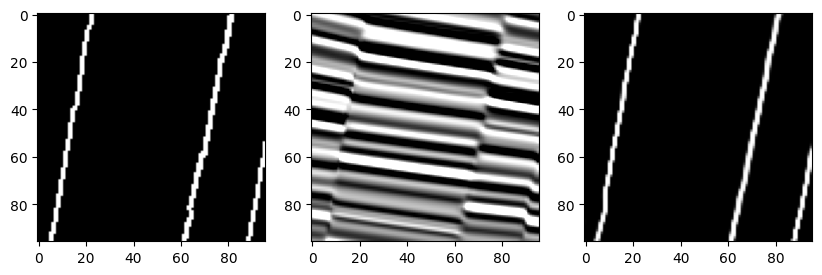

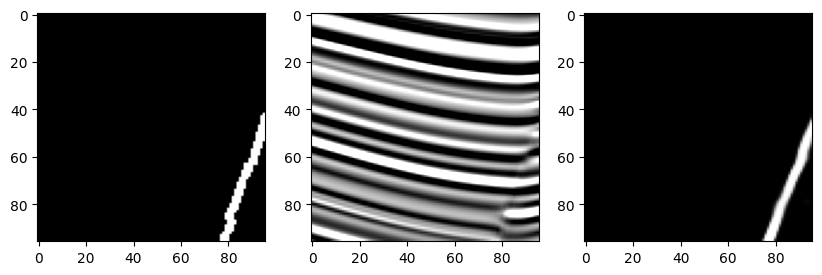

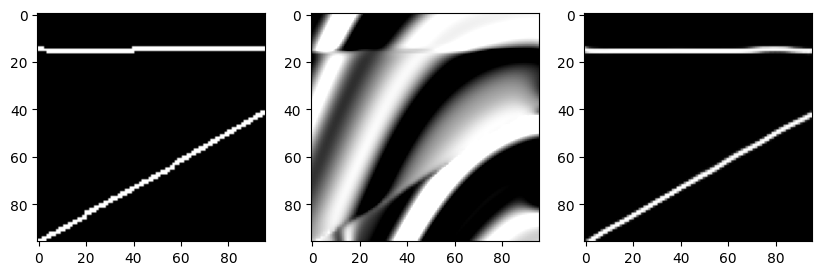

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


graw = np.fromfile("data/validation/seis/8.dat", dtype=np.single).reshape(128, 128, 128)[:96, :96, :96].T
fault = np.fromfile("data/validation/fault/8.dat", dtype=np.single).reshape(128, 128, 128)[:96, :96, :96].T

graw = (graw - np.mean(graw)) / (np.std(graw) + 1e-8)
x = np.reshape(graw, (1, 96, 96, 96, 1))
Y = loaded_model.predict(x, verbose=1)

fig, ax = plt.subplots(1, 3, figsize=(10, 10),)


ax[0].imshow(fault[:, :, 40], cmap="gray", vmin=0, vmax=1)

ax[1].imshow(graw [:, :, 40], cmap="gray", vmin=-1, vmax=1)

ax[2].imshow(Y[0, :, :, 40, 0], cmap="gray", vmin=0, vmax=1)
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(10, 10),)

ax[0].imshow(fault[:, 40, :], cmap="gray", vmin=0, vmax=1)

ax[1].imshow(graw [:, 40, :], cmap="gray", vmin=-1, vmax=1)

ax[2].imshow(Y[0, :, 40, :, 0], cmap="gray", vmin=0, vmax=1)

plt.show()
fig, ax = plt.subplots(1, 3, figsize=(10, 10),)

ax[0].imshow(fault[40 , :, :], cmap="gray", vmin=0, vmax=1)

ax[1].imshow(graw [40, :, :], cmap="gray", vmin=-1, vmax=1)

ax[2].imshow(Y[0, 40, :, :, 0], cmap="gray", vmin=0, vmax=1)

plt.show()

1/1 [==============================] - 0s 24ms/step


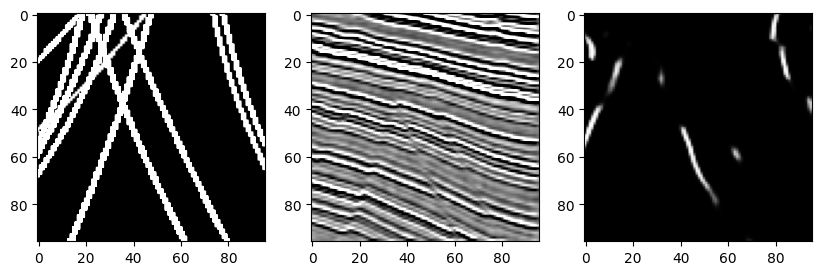

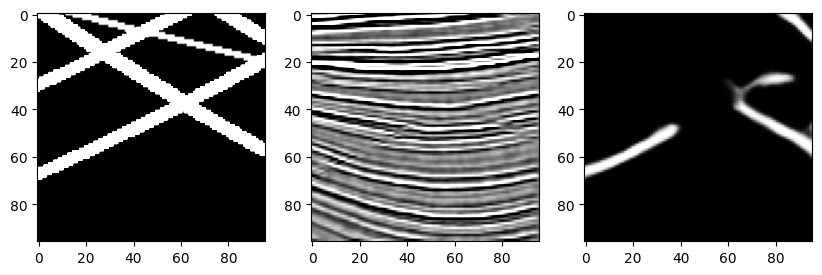

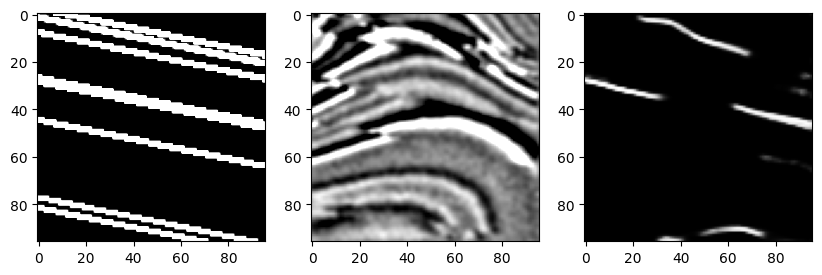

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


graw = np.fromfile("../geofwi/data/train/seis/11.dat", dtype=np.single).reshape(96, 96, 96).T
fault = np.fromfile("../geofwi/data/train/fault/11.dat", dtype=np.single).reshape(96, 96, 96).T

graw = (graw - np.mean(graw)) / (np.std(graw) + 1e-8)
x = np.reshape(graw, (1, 96, 96, 96, 1))
Y = loaded_model.predict(x, verbose=1)

fig, ax = plt.subplots(1, 3, figsize=(10, 10),)


ax[0].imshow(fault[:, :, 40], cmap="gray", vmin=0, vmax=1)

ax[1].imshow(graw [:, :, 40], cmap="gray", vmin=-1, vmax=1)

ax[2].imshow(Y[0, :, :, 40, 0], cmap="gray", vmin=0, vmax=1)
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(10, 10),)

ax[0].imshow(fault[:, 40, :], cmap="gray", vmin=0, vmax=1)

ax[1].imshow(graw [:, 40, :], cmap="gray", vmin=-1, vmax=1)

ax[2].imshow(Y[0, :, 40, :, 0], cmap="gray", vmin=0, vmax=1)

plt.show()
fig, ax = plt.subplots(1, 3, figsize=(10, 10),)

ax[0].imshow(fault[40 , :, :], cmap="gray", vmin=0, vmax=1)

ax[1].imshow(graw [40, :, :], cmap="gray", vmin=-1, vmax=1)

ax[2].imshow(Y[0, 40, :, :, 0], cmap="gray", vmin=0, vmax=1)

plt.show()

 
## ======================================================================

## prediction test on a field seismic image extracted from

## the Netherlands off-shore F3 block seismic data

In [7]:
gx,m1,m2,m3 = np.fromfile("data/prediction/f3d/gxl.dat",dtype=np.single),512,384,128 #(x, y, z)
os = 12 #overlap width
c1 = np.round((m1+os)/(n1-os)+0.5)
c2 = np.round((m2+os)/(n2-os)+0.5)
c3 = np.round((m3+os)/(n3-os)+0.5)
c1 = int(c1)
c2 = int(c2)
c3 = int(c3)
p1 = (n1-os)*c1+os
p2 = (n2-os)*c2+os
p3 = (n3-os)*c3+os
gx = np.reshape(gx,(m1,m2,m3))
gp = np.zeros((p1,p2,p3),dtype=np.single)
gy = np.zeros((p1,p2,p3),dtype=np.single)
mk = np.zeros((p1,p2,p3),dtype=np.single)
gs = np.zeros((1,n1,n2,n3,1),dtype=np.single)

gp[0:m1,0:m2,0:m3]=gx
sc = getMask(os, n1, n2, n3)

# FIX 1: Initialize gs for (z, y, x) dimensions
gs = np.zeros((1, n3, n2, n1, 1), dtype=np.single)

for k1 in range(c1):
    for k2 in range(c2):
        for k3 in range(c3):
            b1 = k1*n1-k1*os
            e1 = b1+n1
            b2 = k2*n2-k2*os
            e2 = b2+n2
            b3 = k3*n3-k3*os
            e3 = b3+n3
            
            # Extract patch in (x, y, z)
            patch = gp[b1:e1,b2:e2,b3:e3]
            
            # Preprocessing
            patch = patch - np.mean(patch)
            patch = patch / (np.std(patch) + 1e-8)
            
            # Transpose to (z, y, x)
            patch = np.transpose(patch)
            gs[0,:,:,:,0] = patch
            
            # Predict (Output is in z, y, x)
            Y = loaded_model.predict(gs, verbose=0)
            Y = np.array(Y)
            
            # FIX 2: Transpose prediction BACK to (x, y, z)
            y_patch = np.transpose(Y[0,:,:,:,0])
            
            # Safely multiply by mask and accumulate
            gy[b1:e1,b2:e2,b3:e3] += y_patch * sc
            mk[b1:e1,b2:e2,b3:e3] += sc

# Normalize overlap and trim to original size
gy = gy/mk
gy = gy[0:m1,0:m2,0:m3]
gy.tofile("data/prediction/f3d/fp.dat", format="%4")

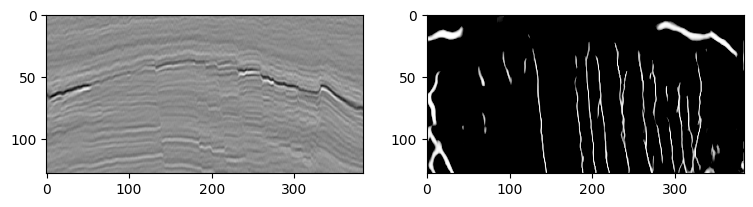

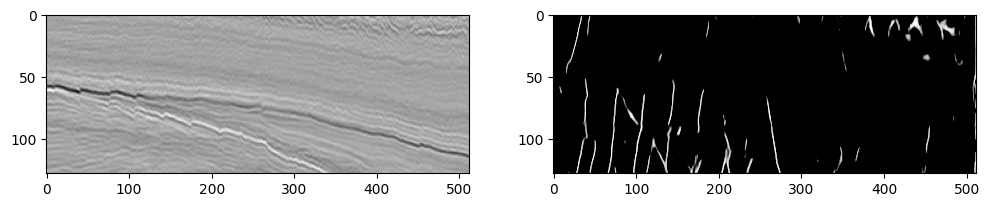

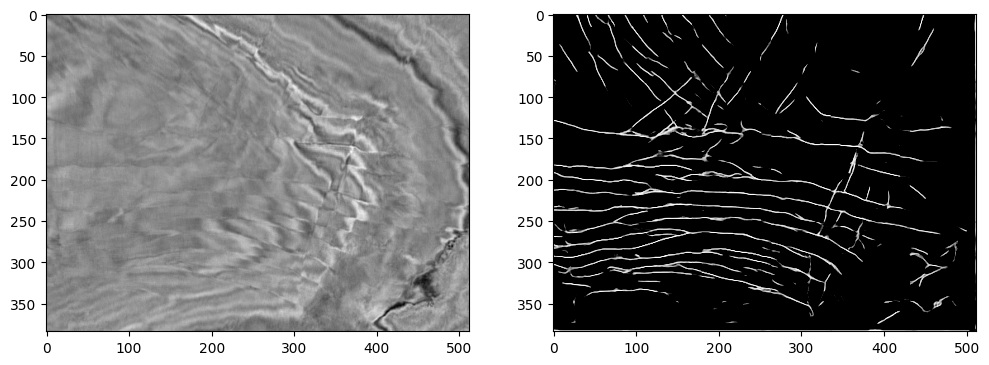

In [8]:
from matplotlib.colors import Normalize
from PIL import Image
gx,m1,m2,m3 = np.fromfile("data/prediction/f3d/gxl.dat",dtype=np.single),512,384,128
gy.tofile("data/prediction/f3d/"+"fp.dat",format="%4")
gx = np.reshape(gx,(m1,m2,m3))
gy = np.reshape(gy,(m1,m2,m3))

k1,k2,k3 = 29,29,95
gx1 = np.transpose(gx[k1,:,:])
gy1 = np.transpose(gy[k1,:,:])
gx2 = np.transpose(gx[:,k2,:])
gy2 = np.transpose(gy[:,k2,:])
gx3 = np.transpose(gx[:,:,k3])
gy3 = np.transpose(gy[:,:,k3])

#xline slice
fig = plt.figure(figsize=(9,9))
p1 = plt.subplot(1, 2, 1)
p1.imshow(gx1,aspect=1.5,cmap=plt.cm.gray)
p2 = plt.subplot(1,2,2)
p2.imshow(gy1,aspect=1.5,interpolation="bilinear",vmin=0.4,vmax=1.0,cmap=plt.cm.gray)

#inline slice
fig = plt.figure(figsize=(12,12))
p1 = plt.subplot(1, 2, 1)
p1.imshow(gx2,aspect=1.5,cmap=plt.cm.gray)
p2 = plt.subplot(1,2,2)
p2.imshow(gy2,aspect=1.5,interpolation="bilinear",vmin=0.4,vmax=1.0,cmap=plt.cm.gray)

#time slice
fig = plt.figure(figsize=(12,12))
p1 = plt.subplot(1, 2, 1)
p1.imshow(gx3,cmap=plt.cm.gray)
p2 = plt.subplot(1,2,2)
p2.imshow(gy3,interpolation="bilinear",vmin=0.4,vmax=1.0,cmap=plt.cm.gray)


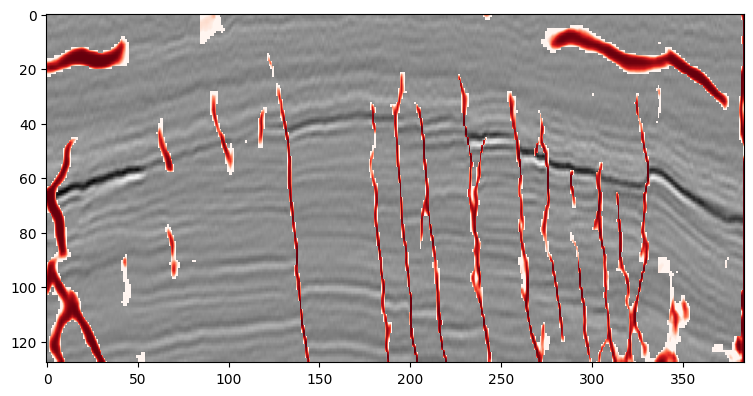

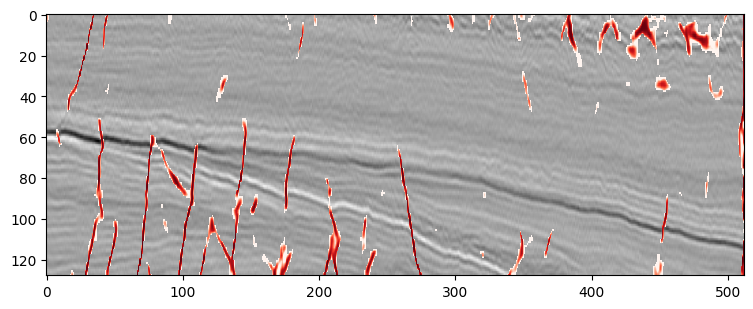

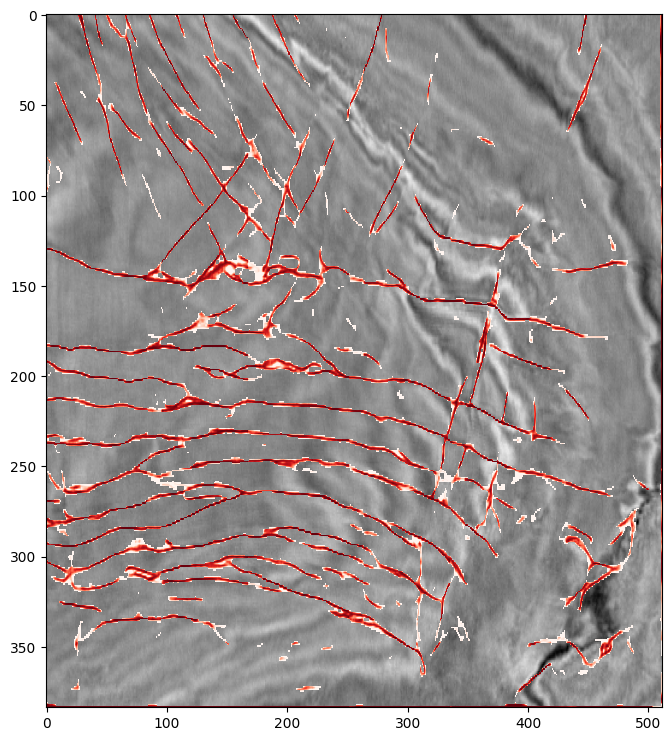

In [9]:
plt.figure(figsize=(9,9))
plt.imshow(gx1,aspect=1.5,cmap=plt.cm.gray)
# zeros to nan
gy1[gy1 < .1] = np.nan
plt.imshow(gy1,aspect=1.5,interpolation="bilinear",vmin=0.4,vmax=1.0,cmap=plt.cm.Reds, alpha=1)
plt.show()

plt.figure(figsize=(9,9))
plt.imshow(gx2,aspect=1.5,cmap=plt.cm.gray)
# zeros to nan
gy2[gy2 < .1] = np.nan
plt.imshow(gy2,aspect=1.5,interpolation="bilinear",vmin=0.4,vmax=1.0,cmap=plt.cm.Reds, alpha=1)
plt.show()

plt.figure(figsize=(9,9))
plt.imshow(gx3,aspect=1.5,cmap=plt.cm.gray)
# zeros to nan
gy3[gy3 < .1] = np.nan
plt.imshow(gy3,aspect=1.5,interpolation="bilinear",vmin=0.4,vmax=1.0,cmap=plt.cm.Reds, alpha=1)
plt.show()
